# EDA — Độ lệch giao hàng và review xấu trên Tiki

**Đồ án:** *Bẻ gãy bẫy SLA trong thương mại điện tử* · Python for Data Science · PGS.TS Nguyễn Mạnh Hùng · HCMUTE HK1 2025–2026
**Nhóm:** Phan Ngô Quốc An (24139002) · Đỗ Minh Hiển (24139013) · Nguyễn Ngọc Ngân (24139031) · Hồ Ngọc Sỹ (24139047)

## Bài toán

| | |
|---|---|
| **Câu hỏi kinh doanh** | Tỉ lệ đạt SLA ("giao trong 1–5 ngày") có phản ánh trải nghiệm khách hàng không? |
| **Bài toán mô hình** | Phân loại nhị phân, dự báo **lúc đơn vừa giao tới tay khách**, trước khi khách viết review |
| **Input** | 17 feature đã biết tại thời điểm đó — 6 nhóm: giao hàng · thời điểm mua · sản phẩm · lịch sử sản phẩm · lịch sử nhà bán · lịch sử khách |
| **Output** | `P(is_low_rating = 1)` — xác suất khách sẽ chấm **≤ 3★** |
| **Dữ liệu** | Tự cào từ Tiki public API (không dùng dataset có sẵn): review + timeline giao hàng + thông tin sản phẩm |

Notebook này trả lời: dữ liệu trông thế nào, sạch tới đâu, biến mục tiêu và feature phân bố ra sao, feature nào
mang tín hiệu — và **mỗi phát hiện dẫn tới quyết định gì trong pipeline** (`main.py`). Mục cuối gom các quyết định đó
thành một bảng.

> **Quy tắc đọc số:** mẫu được cào **phân tầng theo số sao** (vét cạn review 1–3★, lấy mẫu review 4–5★), nên mỗi review
> mang trọng số khảo sát `w = N_h / n_h`. Mọi con số "quần thể" dưới đây đều **nhân trọng số**; con số "thô" chỉ để so
> sánh và cho thấy đếm thô sai thế nào.

In [1]:
import os
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:  # chạy được từ notebooks/ hoặc thư mục gốc
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.evaluate.stats import effective_sample_size, weighted_quantile
from src.features.build import (EX_ANTE_FEATURES, EX_POST_FEATURES, FEATURE_GROUPS, SLA_FEATURE, TARGET,
                                WEIGHT, YEAR, build_features, temporal_split)
from src.features.leakage import FORBIDDEN
from src.models.diagnostics import univariate_auc_table
from src.models.splits import YearForwardSplit
from src.validate.contract import validate_clean_reviews
from src.viz.eda import plot_lead_days_hist, plot_rating_distribution, plot_sla_2x2, plot_sla_by_year
from src.viz.theme import PALETTE, setup_theme

setup_theme()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

clean = pd.read_parquet("data/processed/reviews_clean.parquet")   # bảng review đã làm sạch (python -m src.clean.run_clean)
products = pd.read_parquet("data/raw/tiki_products.parquet")      # bảng sản phẩm
frame = build_features(clean, products)                            # bảng mô hình: meta + feature (dòng phân tích được)
NUMERIC = [f for f in EX_ANTE_FEATURES if f != "category"]
print(f"clean: {clean.shape} · products: {products.shape} · frame (mô hình): {frame.shape}")


def rate_table(df: pd.DataFrame, by, target: str = TARGET) -> pd.DataFrame:
    # Tỉ lệ review xấu theo nhóm: đếm thô vs nhân trọng số, kèm cỡ mẫu hiệu dụng n_eff.
    def one(d: pd.DataFrame) -> pd.Series:
        w = d[WEIGHT].to_numpy(dtype=float)
        return pd.Series({"n": len(d), "n_eff": effective_sample_size(w),
                          "tỉ_lệ_thô": d[target].mean(), "tỉ_lệ_quần_thể": np.average(d[target], weights=w),
                          "tỷ_trọng_quần_thể": w.sum()})
    out = df.groupby(by, observed=True).apply(one)
    out["tỷ_trọng_quần_thể"] /= out["tỷ_trọng_quần_thể"].sum()
    return out.astype({"n": int, "n_eff": int})


PCT = {"tỉ_lệ_thô": "{:.2%}", "tỉ_lệ_quần_thể": "{:.2%}", "tỷ_trọng_quần_thể": "{:.1%}", "n": "{:,}", "n_eff": "{:,}"}

clean: (203510, 43) · products: (2438, 16) · frame (mô hình): (198355, 34)


## 1. Tổng quan dữ liệu và cách thu thập

**Nguồn:** ba endpoint công khai của Tiki (đã đọc `robots.txt`, chỉ dùng endpoint được phép; 1 request/giây, cache xuống
đĩa, User-Agent khai rõ mục đích học thuật):

| Endpoint | Dùng để |
|---|---|
| `api/personalish/v1/blocks/listings?category=…` | liệt kê sản phẩm bán chạy của 10 ngành hàng |
| `api/v2/products/{id}` | giá, giảm giá, nhà bán, ngành hàng |
| `api/v2/reviews?product_id=…&sort=stars\|N` | review + mốc mua/giao/đăng + bộ câu hỏi giao hàng `delivery_rating` |

**Cách lấy mẫu:** cào theo mặc định thì ~96% review là 5★ — biến mục tiêu gần như không có phương sai. Response review
luôn kèm **histogram số sao ở cấp quần thể** (đếm thật), nên nhóm biết đúng kích thước `N_h` của từng tầng sao, cào
**vét cạn** các tầng hiếm 1–3★, **lấy mẫu** tầng 4–5★, rồi gắn trọng số `w = N_h / n_h` (survey sampling).

### 1.1 Kích thước và phạm vi

In [2]:
overview = pd.Series({
    "Số review (dòng)": f"{len(clean):,}",
    "Số cột": clean.shape[1],
    "Số sản phẩm": f"{clean['product_id'].nunique():,}",
    "Số nhà bán": f"{clean['seller_id'].nunique():,}",
    "Số ngành hàng": clean["category_id"].nunique(),
    "Số khách hàng (ẩn danh)": f"{clean['customer_id'].nunique():,}",
    "Mua sớm nhất → muộn nhất": f"{clean['purchased_ts'].min():%Y-%m-%d} → {clean['purchased_ts'].max():%Y-%m-%d}",
    "Quần thể mà mẫu đại diện (Σ trọng số)": f"{clean[WEIGHT].sum():,.0f} review",
    "Σ review_count của sản phẩm (endpoint khác)": f"{products['review_count'].sum():,.0f} review",
}, name="giá trị")
display(overview.to_frame())

,giá trị
Số review (dòng),"203,510"
Số cột,43
Số sản phẩm,"2,438"
Số nhà bán,366
Số ngành hàng,10
Số khách hàng (ẩn danh),"146,241"
Mua sớm nhất → muộn nhất,2012-05-19 → 2026-09-07
Quần thể mà mẫu đại diện (Σ trọng số),"438,255 review"
Σ review_count của sản phẩm (endpoint khác),"438,295 review"


Hai dòng cuối là một **kiểm chứng độc lập** của thiết kế trọng số: tổng trọng số (tính từ histogram sao ở endpoint
review) khớp với tổng `review_count` lấy từ endpoint sản phẩm — lệch chưa tới 0,01%.

### 1.2 Từ điển các cột chính

| Cột | Ý nghĩa | Trường gốc Tiki |
|---|---|---|
| `rating` | số sao khách chấm (1–5) → nhãn `is_low_rating = rating ≤ 3` | `rating` |
| `purchased_ts` | thời điểm đặt mua (đổi từ epoch UTC sang giờ Việt Nam) | `created_by.purchased_at` |
| `delivered_ts` | thời điểm giao tới khách (giờ Việt Nam) | `timeline.delivery_date` |
| `review_ts` | thời điểm đăng review | `timeline.review_created_date` |
| `lead_days` | thời gian giao thực tế = `delivered_ts − purchased_ts` (ngày) | tính ra |
| `sla_breach` | 1 nếu `lead_days > 5` (SLA công bố của Tiki: 1–5 ngày) | tính ra |
| `dr_thoi_gian`, `dr_shipper`, `dr_gio_giao`, `dr_dong_goi` | bộ 4 câu hỏi giao hàng khách tự trả lời (vd "Giao đúng hẹn"/"Giao trễ hẹn") | `delivery_rating[]` |
| `customer_joined` | ngày khách lập tài khoản | `created_by.created_time` |
| `category_name`, `seller_id`, `product_id` | ngành hàng, nhà bán, sản phẩm | `products/{id}` |
| `stratum`, `stratum_size`, `stratum_sampled` | tầng sao · `N_h` · `n_h` | histogram `stars` |
| `weight` | trọng số khảo sát `N_h / n_h` | tính ra |
| `quality_flag`, `is_analysable` | cờ chất lượng dòng (mục 2) | tính ra |

### 1.3 Vài dòng mẫu (bỏ nội dung review và định danh khách)

In [3]:
show_cols = ["review_id", "category_name", "rating", "purchased_ts", "delivered_ts", "review_ts", "lead_days",
             "sla_breach", "dr_thoi_gian", "n_images", "stratum_size", "stratum_sampled", WEIGHT]
display(clean[show_cols].sample(6, random_state=7))
print(clean.dtypes.value_counts().rename("số cột theo kiểu dữ liệu").to_string())

,review_id,category_name,rating,purchased_ts,delivered_ts,review_ts,lead_days,sla_breach,dr_thoi_gian,n_images,stratum_size,stratum_sampled,weight
74894,19809445,Nhà cửa - Đời sống,5,2024-03-09 15:51:57,2024-03-11 15:56:22,2024-03-17 13:48:42,2.0031,False,None,0,99,99,1.0000
14625,18269370,Làm đẹp - Sức khỏe,5,2022-11-22 14:34:33,2022-11-22 16:18:17,2022-11-23 13:26:50,0.0720,False,None,0,108,108,1.0000
200590,19258737,Mẹ và bé,4,2023-03-29 14:02:05,2023-04-02 13:29:19,2023-06-04 11:03:33,3.9772,False,None,0,2,2,1.0000
107335,3711314,Sách tiếng Việt,4,2019-10-07 00:24:32,2019-10-07 13:44:16,2020-06-04 10:18:29,0.5554,False,None,0,16,16,1.0000
87658,14329752,Nhà cửa - Đời sống,5,2021-12-21 10:20:28,2021-12-30 16:15:03,2022-01-08 18:08:00,9.2462,True,None,0,197,197,1.0000
88393,13108417,Nhà cửa - Đời sống,5,2022-06-12 23:49:30,2021-11-07 17:26:02,2021-11-10 14:57:40,-217.2663,None,None,3,4044,200,20.2200


object            18
int64             13
float64            5
bool               4
datetime64[us]     3


### 1.4 Thiết kế lấy mẫu phân tầng: mẫu ≠ quần thể

In [4]:
strata = clean.groupby("rating").agg(n_mẫu=("review_id", "size"), N_quần_thể=(WEIGHT, "sum"))
strata["% trong mẫu"] = strata["n_mẫu"] / strata["n_mẫu"].sum()
strata["% trong quần thể"] = strata["N_quần_thể"] / strata["N_quần_thể"].sum()
strata["trọng số TB (N/n)"] = strata["N_quần_thể"] / strata["n_mẫu"]
display(strata.style.format({"n_mẫu": "{:,}", "N_quần_thể": "{:,.0f}", "% trong mẫu": "{:.1%}",
                             "% trong quần thể": "{:.1%}", "trọng số TB (N/n)": "{:.2f}"}))

,n_mẫu,N_quần_thể,% trong mẫu,% trong quần thể,trọng số TB (N/n)
rating,,,,,
1,"6,454","6,456",3.2%,1.5%,1.00
2,"3,105","3,107",1.5%,0.7%,1.00
3,"7,866","7,868",3.9%,1.8%,1.00
4,"38,819","45,080",19.1%,10.3%,1.16
5,"147,266","375,744",72.4%,85.7%,2.55


Review 1★ được cào gần như **toàn bộ** (trọng số ≈ 1), còn mỗi review 5★ trong mẫu "đại diện" cho vài review 5★ của
quần thể. Nhờ vậy mẫu có đủ ca xấu để mô hình học, mà ước lượng quần thể vẫn không chệch khi nhân trọng số.
**Hệ quả cho pipeline:** trọng số khảo sát phải đi vào cả lúc *đánh giá* (metric là ước lượng quần thể) và lúc *train*
(mục 5.3 cho thấy vì sao).

## 2. Chất lượng dữ liệu

### 2.1 Data contract — bộ kiểm tra tự động chạy sau mỗi lần làm sạch

In [5]:
print(validate_clean_reviews(clean))

Data contract: 22/22 đạt
  ✓ đủ cột bắt buộc
  ✓ bảng không rỗng — n=203510
  ✓ bản sao review_id phải trùng khớp nội dung — 0 bản sao, 0 bản sao mâu thuẫn
  ✓ rating ∈ {1..5} — 0 dòng ngoài khoảng
  ✓ độ phủ purchased_at ≥ 95% — thực tế 99.9%
  ✓ độ phủ delivery_date ≥ 90% — thực tế 98.4%
  ✓ độ phủ review_created_date ≥ 90% — thực tế 98.4%
  ✓ độ phủ nhãn giao hàng ≥ 5% — thực tế 7.9%
  ✓ stratum khớp rating — 0 dòng lệch
  ✓ số lấy mẫu ≤ kích thước tầng — 0 dòng vi phạm
  ✓ trọng số ≥ 1 và không rỗng — 0 dòng sai
  ✓ có cột lead_days
  ✓ có cột gap_days
  ✓ có cột quality_flag
  ✓ có cột is_analysable
  ✓ có cột sla_breach
  ✓ review_id là khoá duy nhất (sau khử trùng lặp) — 0 dòng trùng
  ✓ còn dòng phân tích được — 198355/203510 dòng
  ✓ dòng phân tích được không có lead_days âm — 0 dòng
  ✓ gap_days = lead_days − SLA — sai lệch lớn nhất 0.00e+00
  ✓ dòng phân tích được đều có gap_days — 0 dòng rỗng
  ✓ dòng bị loại có gap_days rỗng — 0 dòng rò rỉ


### 2.2 Giá trị thiếu

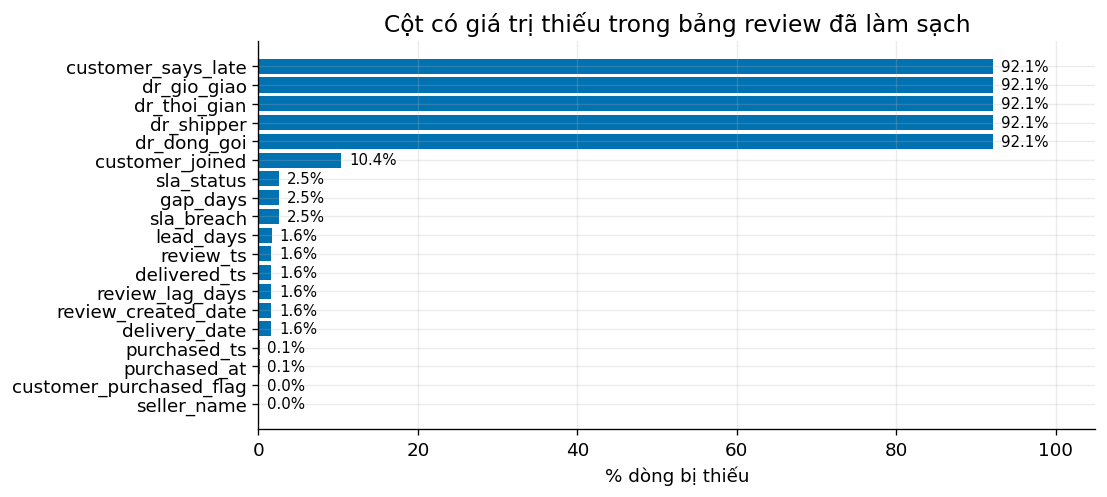

Thiếu trong 17 feature của mô hình: {'cust_tenure_days': '10.29%'}
   thiếu cust_tenure_days   n= 20,413  tỉ lệ review ≤3★ (quần thể) = 10.66%
   có cust_tenure_days      n=177,942  tỉ lệ review ≤3★ (quần thể) = 3.29%


In [6]:
missing = clean.isna().mean()
missing = missing[missing > 0].sort_values()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(missing.index, missing.values * 100, color=PALETTE[0])
for y, v in enumerate(missing.values):
    ax.text(v * 100 + 1, y, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlabel("% dòng bị thiếu")
ax.set_title("Cột có giá trị thiếu trong bảng review đã làm sạch")
ax.set_xlim(0, 105)
plt.show()

feat_missing = frame[EX_ANTE_FEATURES].isna().mean()
print("Thiếu trong 17 feature của mô hình:", feat_missing[feat_missing > 0].map("{:.2%}".format).to_dict())
tenure_missing = frame["cust_tenure_days"].isna()
for label, m in (("thiếu cust_tenure_days", tenure_missing), ("có cust_tenure_days", ~tenure_missing)):
    d = frame[m]
    print(f"   {label:24s} n={len(d):7,}  tỉ lệ review ≤3★ (quần thể) = {np.average(d[TARGET], weights=d[WEIGHT]):.2%}")

* Thiếu nhiều nhất là bộ câu hỏi giao hàng `dr_*` (~92%) — **thiếu do thiết kế**: trường này chưa tồn tại trước 2023
  (mục 7–8), không phải lỗi cào. Chúng không vào mô hình dự báo.
* Các mốc thời gian thiếu ~1,5% → không tính được thời gian giao → dòng bị loại khỏi phân tích (mục 2.3).
* Trong 17 feature của mô hình chỉ `cust_tenure_days` thiếu (10,3%). Khách thiếu thông tin này có tỉ lệ review xấu
  **cao gấp ~3 lần** khách có thông tin → **việc thiếu tự nó là tín hiệu**.
  ⇒ Pipeline: `SimpleImputer(strategy="median", add_indicator=True)` — điền trung vị *và* thêm cột cờ "đã thiếu".

### 2.3 Dòng nào dùng được để phân tích thời gian giao hàng?

In [7]:
flags = clean["quality_flag"].value_counts().to_frame("số dòng")
flags["tỉ lệ"] = flags["số dòng"] / len(clean)
display(flags.style.format({"số dòng": "{:,}", "tỉ lệ": "{:.2%}"}))

neg = clean[clean["quality_flag"] == "lead_days âm"]
ok = clean[clean["is_analysable"]]
print(f"Rating TB có trọng số — dòng lead âm: {np.average(neg['rating'], weights=neg[WEIGHT]):.3f} · "
      f"dòng hợp lệ: {np.average(ok['rating'], weights=ok[WEIGHT]):.3f}")

,số dòng,tỉ lệ
quality_flag,,
ok,"198,355",97.47%
thiếu delivery_date,"3,064",1.51%
lead_days âm,"1,799",0.88%
thiếu purchased_at,280,0.14%
lead_days > 90 ngày,12,0.01%


Rating TB có trọng số — dòng lead âm: 4.770 · dòng hợp lệ: 4.784


**97,47%** dòng dùng được. Nhóm lỗi đáng chú ý nhất là **0,88% dòng có thời gian giao âm** (dòng cuối của bảng mẫu
1.3 là một ví dụ: −217 ngày). Nhóm đã truy ra nguyên nhân: `purchased_at` ghi lần mua *gần nhất* của khách với sản phẩm
đó, nên khi khách mua lại sau khi đã review thì mốc mua không còn cùng đơn với mốc giao. Các dòng này **được gắn cờ và
loại khỏi phân tích thời gian giao, không xoá im lặng**; rating trung bình có trọng số của nhóm bị loại (4,770) gần như
bằng nhóm giữ lại (4,784) → loại chúng không làm lệch kết luận.

Một lỗi im lặng khác đã sửa ở bước làm sạch: Tiki trả `purchased_at` là epoch **UTC** nhưng `delivery_date` là chuỗi
**giờ Việt Nam** — trừ thẳng sẽ cộng dư đúng 7 giờ vào mọi lead time. Độ lệch đo được trên 200.290 review là 7,0000 giờ,
độ lệch chuẩn 0 → mọi mốc ở đây đã quy về giờ Việt Nam.

## 3. Biến mục tiêu `is_low_rating` (rating ≤ 3★)

### 3.1 Phân phối số sao: mẫu thô vs quần thể

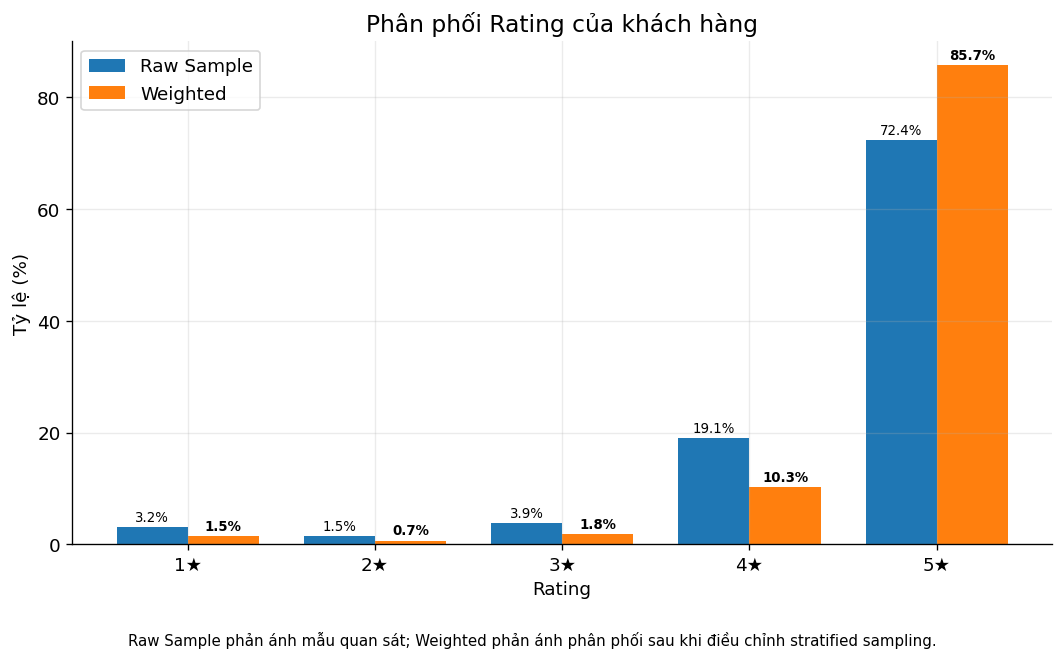

In [8]:
fig, _ = plot_rating_distribution(clean)
plt.show()

### 3.2 Mất cân bằng lớp — và nó thay đổi theo năm

,n,n_eff,tỉ_lệ_thô,tỉ_lệ_quần_thể,tỷ_trọng_quần_thể
year,,,,,
2019,"3,269","1,122",26.06%,11.79%,1.7%
2020,"18,458","5,860",18.88%,10.61%,7.7%
2021,"52,584","13,019",10.72%,5.19%,25.6%
2022,"54,829","14,329",6.59%,2.83%,30.0%
2023,"26,591","7,267",4.53%,1.95%,14.5%
2024,"18,369","6,371",3.62%,1.66%,9.4%
2025,"14,458","4,353",3.52%,1.68%,7.1%
2026,"8,355","2,411",3.48%,1.72%,4.0%


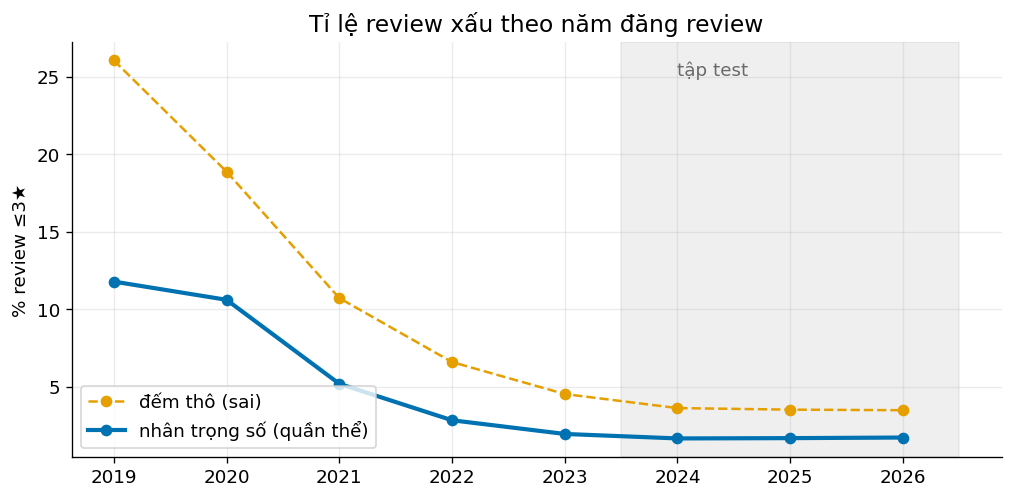

train ≤2023     lớp dương (quần thể) = 4.45% → âm : dương ≈ 21.5 : 1 · đoán toàn 'không xấu' đã đạt accuracy 95.55%
test 2024–2026  lớp dương (quần thể) = 1.68% → âm : dương ≈ 58.6 : 1 · đoán toàn 'không xấu' đã đạt accuracy 98.32%


In [9]:
by_year = rate_table(frame[frame[YEAR] >= 2019], YEAR)
display(by_year.style.format(PCT))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(by_year.index, by_year["tỉ_lệ_thô"] * 100, "o--", color=PALETTE[1], label="đếm thô (sai)")
ax.plot(by_year.index, by_year["tỉ_lệ_quần_thể"] * 100, "o-", color=PALETTE[0], lw=2.5, label="nhân trọng số (quần thể)")
ax.axvspan(2023.5, by_year.index.max() + 0.5, color="grey", alpha=0.12)
ax.text(2024, ax.get_ylim()[1] * 0.92, "tập test", color="dimgrey")
ax.set_ylabel("% review ≤3★")
ax.set_title("Tỉ lệ review xấu theo năm đăng review")
ax.legend()
plt.show()

train, test = temporal_split(frame)
for name, d in (("train ≤2023", train), ("test 2024–2026", test)):
    p = np.average(d[TARGET], weights=d[WEIGHT])
    print(f"{name:15s} lớp dương (quần thể) = {p:.2%} → âm : dương ≈ {(1 - p) / p:.1f} : 1 · "
          f"đoán toàn 'không xấu' đã đạt accuracy {1 - p:.2%}")

* Trong mẫu thô, review ≤3★ chiếm **8,6%**; trong quần thể chỉ **~4%** (bảng 1.4). Đếm thô phóng đại gấp đôi — đúng
  như thiết kế lấy mẫu, và là lý do mọi tỉ lệ phải nhân trọng số.
* **Mất cân bằng nặng và tăng dần theo năm:** 11,8% (2019) → ~1,7% (2024–2026). Train ≤2023: 4,45% (≈ 21,5 : 1);
  test 2024–2026: 1,68% (≈ 58,6 : 1).

**Hệ quả cho pipeline:**
1. **Accuracy vô nghĩa** — đoán toàn "không xấu" đã đúng 98,3% trên test. Thước đo chính là **PR-AUC có trọng số**
   (mốc ngẫu nhiên = tỉ lệ dương), kèm lift, ROC-AUC, Brier skill, ECE và precision/recall ở top 5%.
2. Mất cân bằng xử lý bằng **`class_weight`** (`None` / `"balanced"` / `{1: 21,5}`) — một siêu tham số do CV chọn.
   **Không** oversample/SMOTE: nhân bản dòng sẽ phá trọng số khảo sát `N_h / n_h`.
3. Tỉ lệ trôi theo năm → **chia train/test theo thời gian** (mục 8), và xác suất của mô hình phải **hiệu chỉnh** trên
   năm gần nhất của train thì mới khớp mức của tương lai.

## 4. Feature đầu vào (17 feature ex-ante)

Mỗi feature phải **đã biết lúc đơn được giao tới khách** — đó là thời điểm dự báo. Feature lịch sử (`*_hist_n`,
`*_hist_rate`) tính "as-of": chỉ đếm các review **đã đăng trước** mốc giao của đơn đang xét, có làm trơn về tỉ lệ
chung (prior) khi lịch sử còn ít.

In [10]:
groups = pd.DataFrame([(g, f) for g, fs in FEATURE_GROUPS.items() for f in fs], columns=["nhóm", "feature"])
display(groups.groupby("nhóm", sort=False)["feature"].apply(", ".join).to_frame())

,feature
nhóm,
giao_hang,"lead_days, delivered_hour, delivered_weekend"
thoi_diem_mua,"purchase_month, purchase_weekday, purchase_hour"
san_pham,"category, is_tiki_trading, log_price, discount..."
lich_su_san_pham,"prod_hist_n, prod_hist_rate"
lich_su_nha_ban,"seller_hist_n, seller_hist_rate"
khach_hang,"cust_tenure_days, cust_hist_n, cust_hist_rate"


### 4.1 Thống kê mô tả có trọng số

In [11]:
rows = {}
for f in NUMERIC:
    x = frame[f].to_numpy(dtype=float)
    w = frame[WEIGHT].to_numpy(dtype=float)
    ok_ = ~np.isnan(x)
    q = weighted_quantile(x[ok_], w[ok_], np.array([0.05, 0.5, 0.95]))
    rows[f] = {"% thiếu": 1 - ok_.mean(), "TB (trọng số)": np.average(x[ok_], weights=w[ok_]),
               "p5": q[0], "trung vị": q[1], "p95": q[2], "min": np.nanmin(x), "max": np.nanmax(x),
               "độ lệch (skew)": pd.Series(x).skew(), "số giá trị khác nhau": pd.Series(x).nunique()}
desc = pd.DataFrame(rows).T
display(desc.style.format({"% thiếu": "{:.1%}", "số giá trị khác nhau": "{:,.0f}"}, precision=3)
        .background_gradient(subset=["độ lệch (skew)"], cmap="Oranges"))

,% thiếu,TB (trọng số),p5,trung vị,p95,min,max,độ lệch (skew),số giá trị khác nhau
lead_days,0.0%,2.212,0.076,1.258,5.925,0.000,89.993,8.446,"140,422"
delivered_hour,0.0%,12.405,8.000,12.000,18.000,0.000,23.000,0.450,24
delivered_weekend,0.0%,0.227,0.000,0.000,1.000,0.000,1.000,1.305,2
purchase_month,0.0%,6.582,1.000,7.000,12.000,1.000,12.000,-0.043,12
purchase_weekday,0.0%,2.878,0.000,3.000,6.000,0.000,6.000,0.060,7
purchase_hour,0.0%,13.672,1.000,14.000,22.000,0.000,23.000,-0.302,24
is_tiki_trading,0.0%,0.813,0.000,1.000,1.000,0.000,1.000,-0.746,2
log_price,0.0%,11.939,10.915,11.798,13.333,8.517,17.329,0.832,"1,092"
discount_rate,0.0%,23.718,0.000,25.000,43.000,0.000,84.000,0.243,71
prod_hist_n,0.0%,5.624,2.020,5.867,8.229,0.000,9.499,-0.360,"64,666"


### 4.2 Phân phối từng feature số (có trọng số, cắt p1–p99 để dễ nhìn)

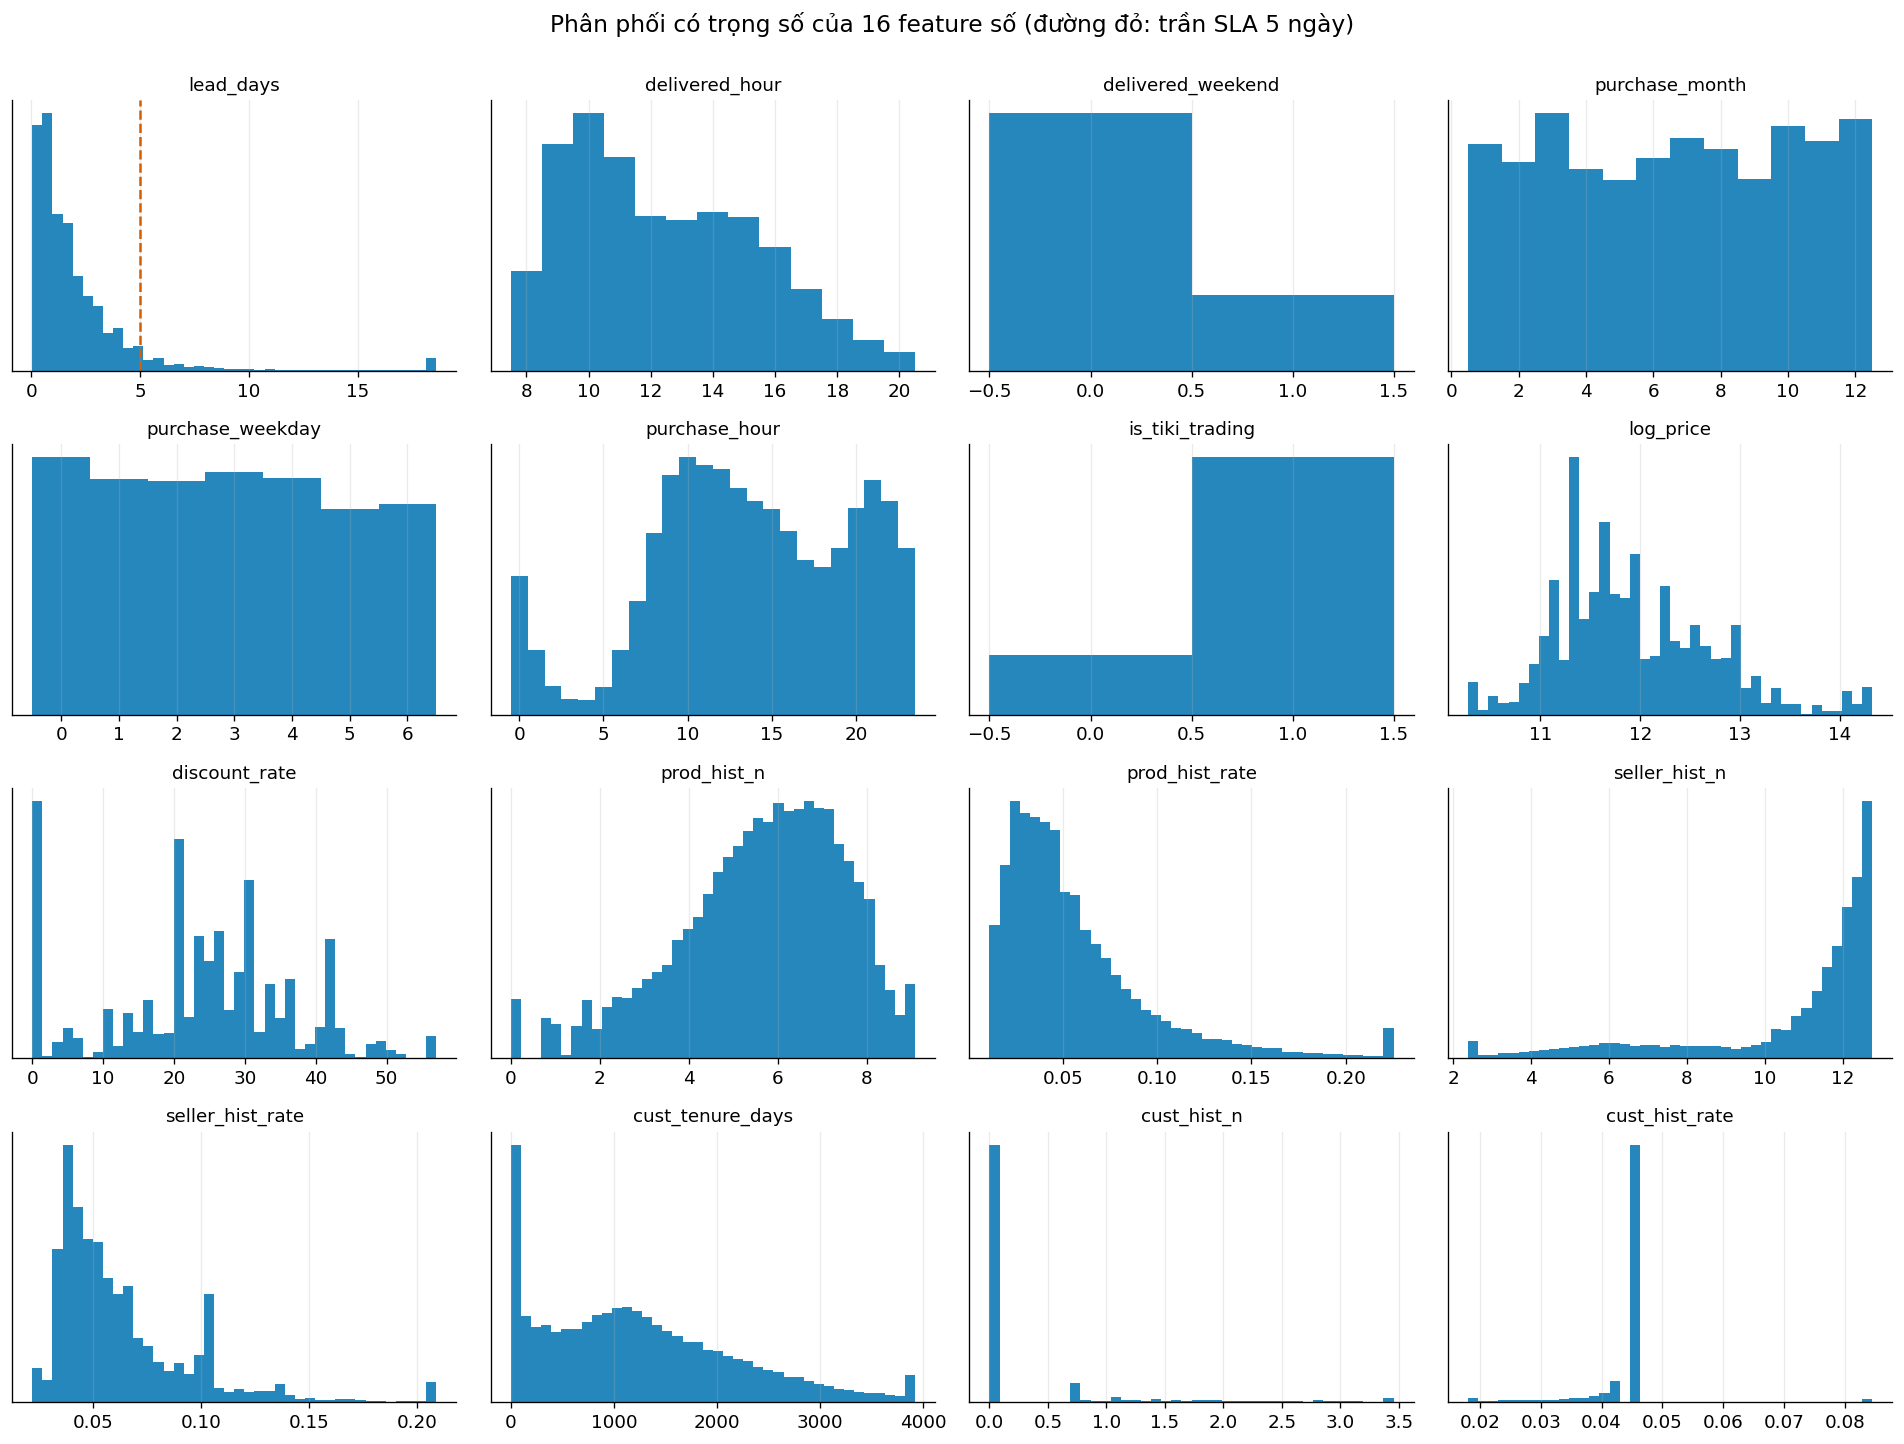

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, f in zip(axes.ravel(), NUMERIC):
    x = frame[f].to_numpy(dtype=float)
    w = frame[WEIGHT].to_numpy(dtype=float)
    ok_ = ~np.isnan(x)
    lo, hi = weighted_quantile(x[ok_], w[ok_], np.array([0.01, 0.99]))
    bins = np.arange(lo - 0.5, hi + 1.5) if pd.Series(x).nunique() <= 31 else 40
    ax.hist(np.clip(x[ok_], lo, hi), bins=bins, weights=w[ok_] / w[ok_].sum(), color=PALETTE[0], alpha=0.85)
    ax.set_title(f, fontsize=11)
    ax.set_yticks([])
    if f == "lead_days":
        ax.axvline(5, color=PALETTE[5], ls="--", lw=1.5)
for ax in axes.ravel()[len(NUMERIC):]:
    ax.axis("off")
fig.suptitle("Phân phối có trọng số của 16 feature số (đường đỏ: trần SLA 5 ngày)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

* **Thang đo chênh nhau hàng nghìn lần** (`cust_tenure_days` tới ~5.800 ngày, các `*_hist_rate` < 0,6)
  ⇒ `StandardScaler` cho cột số — bắt buộc với logistic có phạt L2 (phạt công bằng giữa các hệ số), vô hại với cây.
* `lead_days` **lệch phải nặng** (skew 8,4; trung vị 1,26 ngày nhưng p95 5,9 và max 90 ngày). Giữ nguyên thang: cây
  không nhạy với biến đổi đơn điệu, còn logistic được chính quy hoá mạnh nên vài điểm cực trị không kéo lệch hệ số.
* Các `*_hist_n` đã được `log1p` lúc dựng feature để nén đuôi dài.
* `cust_hist_rate` dồn cục ở ~0,045 = tỉ lệ prior: phần lớn khách **chưa có review nào trước đó**, nên tỉ lệ lịch sử
  của họ được làm trơn về mức chung thay vì để trống hay bằng 0.
* Giờ/thứ/tháng để dạng số nguyên — đủ cho cây; logistic chỉ bắt được xu hướng tuyến tính của chúng (mục 5.2 cho thấy
  tín hiệu ở đây yếu, không đáng mở rộng thành one-hot).

### 4.3 Feature phân loại: ngành hàng

,n,n_eff,tỉ_lệ_thô,tỉ_lệ_quần_thể,tỷ_trọng_quần_thể
category_name,,,,,
Nhà cửa - Đời sống,"66,557","17,647",8.49%,2.68%,49.2%
Thời trang nữ,"33,746","18,467",6.10%,3.81%,12.6%
Mẹ và bé,"33,553","18,574",8.35%,5.31%,12.3%
Sách tiếng Việt,"22,111","6,137",10.79%,4.85%,11.5%
Làm đẹp - Sức khỏe,"19,608","8,139",7.72%,4.84%,7.3%
Nhà sách tiki,"11,687","8,072",12.30%,9.17%,3.7%
Điện gia dụng,"9,487","6,714",7.02%,5.30%,2.9%
Thể thao - Dã ngoại,"1,047","1,047",7.64%,7.64%,0.2%
Điện thoại - Máy tính bảng,537,537,0.93%,0.93%,0.1%


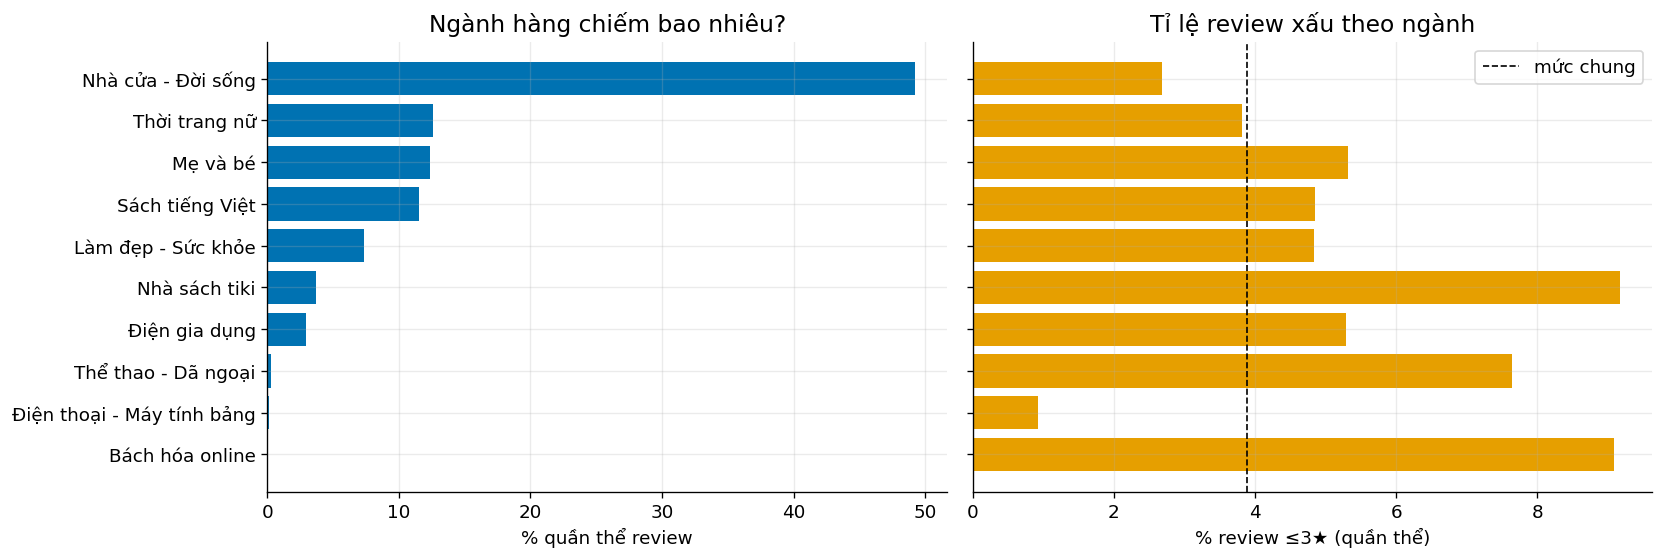

In [13]:
cat = rate_table(frame, "category_name").sort_values("tỷ_trọng_quần_thể")
display(cat.sort_values("tỷ_trọng_quần_thể", ascending=False).style.format(PCT))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
a1.barh(cat.index, cat["tỷ_trọng_quần_thể"] * 100, color=PALETTE[0])
a1.set_xlabel("% quần thể review")
a1.set_title("Ngành hàng chiếm bao nhiêu?")
a2.barh(cat.index, cat["tỉ_lệ_quần_thể"] * 100, color=PALETTE[1])
a2.axvline(np.average(frame[TARGET], weights=frame[WEIGHT]) * 100, color="k", ls="--", lw=1, label="mức chung")
a2.set_xlabel("% review ≤3★ (quần thể)")
a2.set_title("Tỉ lệ review xấu theo ngành")
a2.legend()
plt.tight_layout()
plt.show()

"Nhà cửa – Đời sống" chiếm gần nửa quần thể. Tỉ lệ review xấu giữa các ngành chênh từ 0,9% tới 9,2% → ngành hàng mang
tín hiệu. Ngành là biến **định danh, không có thứ tự**, 10 mức ⇒ `OneHotEncoder(handle_unknown="ignore")` (ngành mới
chưa thấy lúc train sẽ thành vector 0 thay vì làm lỗi). Ba ngành cuối rất nhỏ (n ≤ 1.047) nên tỉ lệ của chúng kém tin
cậy — mô hình có chính quy hoá sẽ không dựa nhiều vào chúng.

## 5. Feature nào mang tín hiệu về review xấu?

### 5.1 Thời gian giao hàng và review xấu

,n,n_eff,tỉ_lệ_thô,tỉ_lệ_quần_thể,tỷ_trọng_quần_thể
nhóm_lead,,,,,
0–1,"77,752","22,331",5.90%,2.59%,41.5%
1–2,"48,522","13,210",8.17%,3.64%,25.5%
2–3,"27,541","7,067",9.49%,4.54%,13.5%
3–5,"28,223","7,449",10.66%,5.67%,12.4%
5–7,"8,103","2,055",13.51%,7.58%,3.4%
7–10,"3,454",878,14.77%,7.39%,1.6%
>10,"4,760","1,113",17.10%,8.95%,2.1%


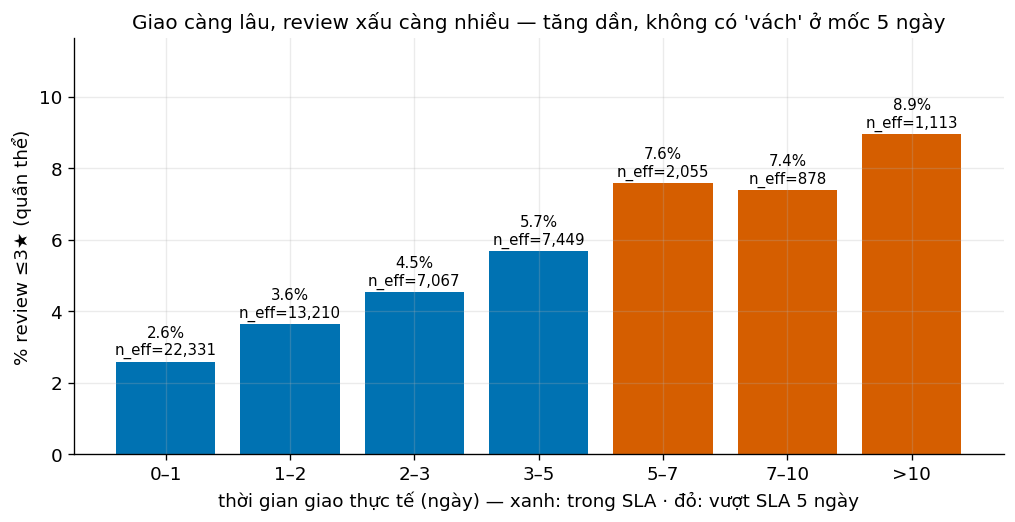

In [14]:
lead_bins = [0, 1, 2, 3, 5, 7, 10, np.inf]
lead_labels = ["0–1", "1–2", "2–3", "3–5", "5–7", "7–10", ">10"]
by_lead = rate_table(frame.assign(nhóm_lead=pd.cut(frame["lead_days"], lead_bins, labels=lead_labels,
                                                   include_lowest=True)), "nhóm_lead")
display(by_lead.style.format(PCT))

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PALETTE[0]] * 4 + [PALETTE[5]] * 3
ax.bar(by_lead.index.astype(str), by_lead["tỉ_lệ_quần_thể"] * 100, color=colors)
for i, (v, n) in enumerate(zip(by_lead["tỉ_lệ_quần_thể"], by_lead["n_eff"])):
    ax.text(i, v * 100 + 0.2, f"{v:.1%}\nn_eff={n:,}", ha="center", fontsize=9)
ax.set_xlabel("thời gian giao thực tế (ngày) — xanh: trong SLA · đỏ: vượt SLA 5 ngày")
ax.set_ylabel("% review ≤3★ (quần thể)")
ax.set_title("Giao càng lâu, review xấu càng nhiều — tăng dần, không có 'vách' ở mốc 5 ngày", fontsize=12)
ax.set_ylim(0, by_lead["tỉ_lệ_quần_thể"].max() * 130)
plt.show()

Tỉ lệ review xấu tăng đều từ **2,6%** (giao trong 1 ngày) lên **5,7%** (3–5 ngày) rồi ~7,5–9% khi vượt SLA. Không có
bước nhảy ở mốc 5 ngày: đơn 3–5 ngày — vẫn "đạt SLA" — đã xấu **gấp đôi** đơn giao trong ngày.
⇒ Mô hình dùng **`lead_days` liên tục**, không dùng cờ `sla_breach` (chỉ là một ngưỡng của `lead_days`, vứt bỏ thông
tin). Cờ SLA chỉ được giữ làm **baseline B1** — "doanh nghiệp đang đo bằng cái này thì dự đoán được bao nhiêu?".

### 5.2 Tỉ lệ review xấu theo từng nhóm giá trị của các feature khác

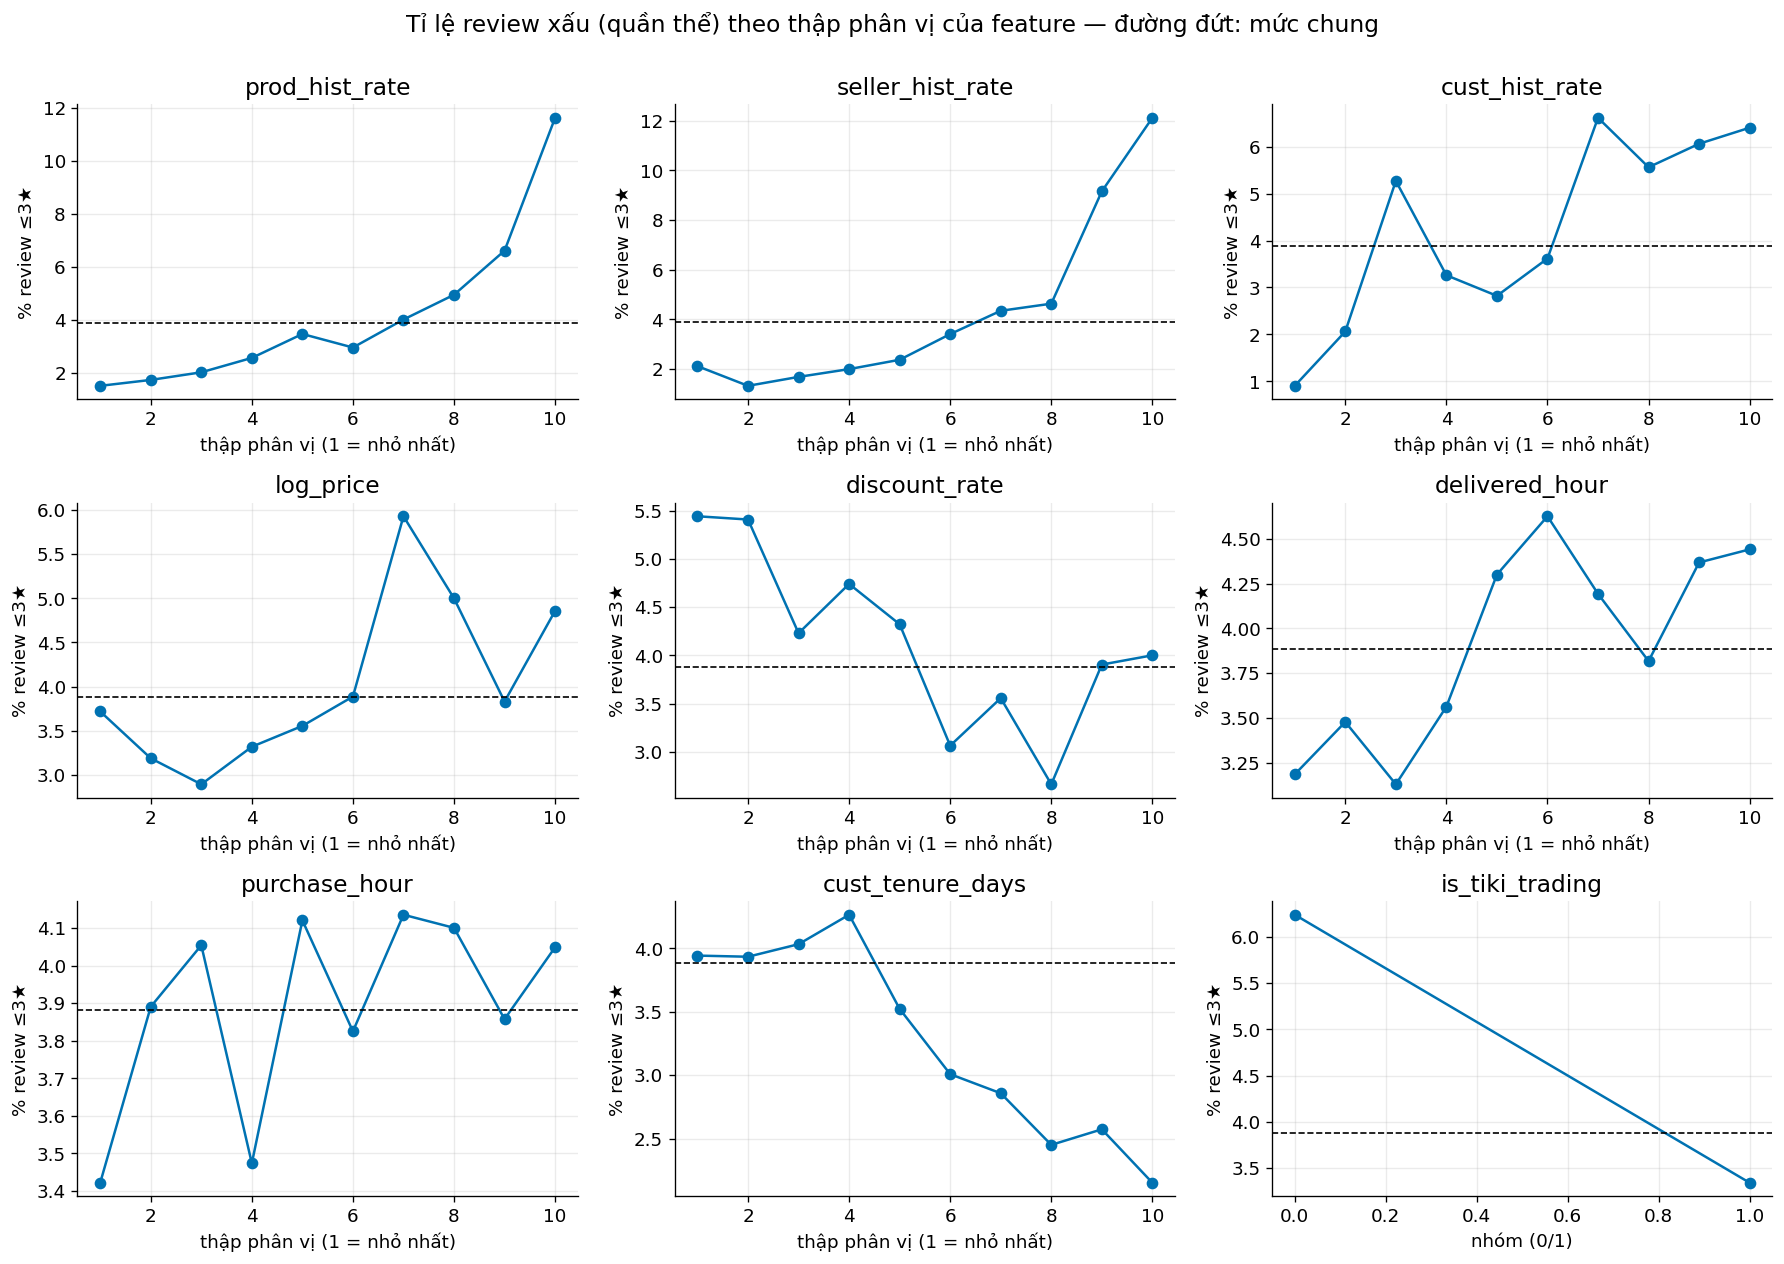

In [15]:
show = ["prod_hist_rate", "seller_hist_rate", "cust_hist_rate", "log_price", "discount_rate", "delivered_hour",
        "purchase_hour", "cust_tenure_days", "is_tiki_trading"]
base = np.average(frame[TARGET], weights=frame[WEIGHT])
fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
for ax, f in zip(axes.ravel(), show):
    d = frame[[f, TARGET, WEIGHT]].dropna()
    groups_ = d[f] if d[f].nunique() <= 2 else pd.qcut(d[f].rank(method="first"), 10, labels=False) + 1
    t = rate_table(d.assign(_g=groups_), "_g")
    ax.plot(t.index, t["tỉ_lệ_quần_thể"] * 100, "o-", color=PALETTE[0])
    ax.axhline(base * 100, color="k", ls="--", lw=1)
    ax.set_title(f)
    ax.set_xlabel("nhóm (0/1)" if d[f].nunique() <= 2 else "thập phân vị (1 = nhỏ nhất)")
    ax.set_ylabel("% review ≤3★")
fig.suptitle("Tỉ lệ review xấu (quần thể) theo thập phân vị của feature — đường đứt: mức chung", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

* **Lịch sử sản phẩm và nhà bán là tín hiệu mạnh nhất:** thập phân vị cao nhất có tỉ lệ review xấu ~12%, gấp 3 lần mức
  chung — sản phẩm/nhà bán từng bị chê thì tiếp tục bị chê.
* Khách lâu năm ít chấm xấu hơn; đơn của **Tiki Trading** ít bị chê hơn nhà bán bên thứ ba (~3,3% vs ~6,2%).
* `purchase_hour` dao động quanh mức chung, gần như không có tín hiệu — vẫn giữ và để chính quy hoá/cây tự quyết, không
  loại tay (loại tay theo EDA trên toàn bộ dữ liệu là một dạng nhìn trộm test).
* Nhiều quan hệ **không đơn điệu** (`log_price`, `delivered_hour`, `discount_rate`) ⇒ cần thêm họ mô hình **cây**
  (RandomForest, HistGBM) bên cạnh logistic.

### 5.3 Sức phân biệt của từng feature: đo trên mẫu thô vs trên quần thể

ROC-AUC của từng feature đứng một mình (chỉ trên tập train ≤2023). AUC = 0,5 là không có tín hiệu; > 0,5 là giá trị
càng lớn càng dễ xấu; < 0,5 là ngược lại. Nếu một feature nằm **hai phía 0,5** giữa hai cột thì quan hệ feature–nhãn
**đảo chiều** do thiết kế lấy mẫu.

,auc_mau_tho,auc_quan_the,đảo_chiều,"|AUC−0,5| quần thể"
seller_hist_rate,0.650,0.679,False,0.179
seller_hist_n,0.453,0.342,False,0.158
prod_hist_rate,0.643,0.657,False,0.157
prod_hist_n,0.554,0.376,True,0.124
lead_days,0.589,0.604,False,0.104
cust_hist_rate,0.557,0.560,False,0.060
cust_hist_n,0.451,0.448,False,0.052
is_tiki_trading,0.527,0.450,True,0.050
log_price,0.523,0.542,False,0.042
cust_tenure_days,0.452,0.465,False,0.035


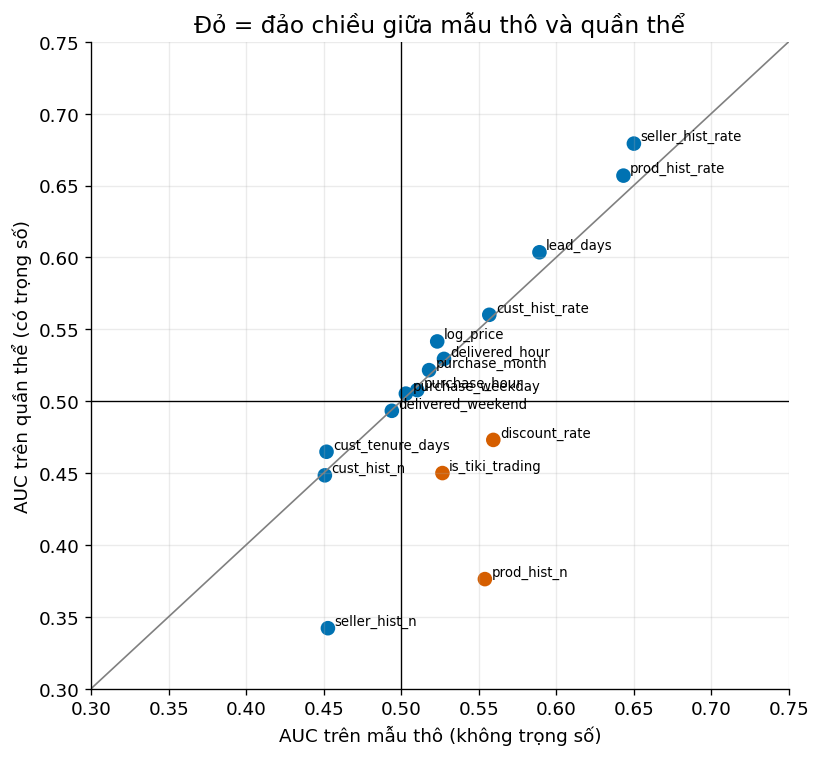

Số feature đảo chiều: 3/16


In [16]:
auc = univariate_auc_table(train, NUMERIC)
auc["|AUC−0,5| quần thể"] = (auc["auc_quan_the"] - 0.5).abs()
auc = auc.sort_values("|AUC−0,5| quần thể", ascending=False)
display(auc.style.format({"auc_mau_tho": "{:.3f}", "auc_quan_the": "{:.3f}", "|AUC−0,5| quần thể": "{:.3f}"})
        .apply(lambda r: ["background-color: #fde2c8" if r["đảo_chiều"] else "" for _ in r], axis=1))

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(auc["auc_mau_tho"], auc["auc_quan_the"], s=60,
           c=[PALETTE[5] if f else PALETTE[0] for f in auc["đảo_chiều"]])
for f, r in auc.iterrows():
    ax.annotate(f, (r["auc_mau_tho"], r["auc_quan_the"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
lim = (0.3, 0.75)
ax.plot(lim, lim, color="grey", lw=1)
ax.axhline(0.5, color="k", lw=0.8)
ax.axvline(0.5, color="k", lw=0.8)
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_xlabel("AUC trên mẫu thô (không trọng số)")
ax.set_ylabel("AUC trên quần thể (có trọng số)")
ax.set_title("Đỏ = đảo chiều giữa mẫu thô và quần thể")
plt.show()
print(f"Số feature đảo chiều: {int(auc['đảo_chiều'].sum())}/{len(auc)}")

* Mạnh nhất đứng một mình: `seller_hist_rate` (0,68), `prod_hist_rate` (0,66), `lead_days` (0,60), cùng
  `seller_hist_n`/`prod_hist_n` theo chiều ngược (nhà bán/sản phẩm càng nhiều review thì càng ít bị chê).
* **3/16 feature đổi phía 0,5** giữa mẫu thô và quần thể: `prod_hist_n` 0,55 → 0,38, `is_tiki_trading` 0,53 → 0,45,
  `discount_rate` 0,56 → 0,47; `seller_hist_n` giữ phía nhưng mạnh lên hẳn (0,45 → 0,34).
* Lý do: xác suất một review 5★ được lấy vào mẫu là `n_h / N_h` — **phụ thuộc sản phẩm** (sản phẩm càng đông review thì
  tầng 5★ càng bị cắt mạnh). Mẫu thô vì thế bóp méo chính quan hệ feature–nhãn mà mô hình cần học.

⇒ **Train có trọng số khảo sát** (`model__sample_weight = w / mean(w)`), không chỉ dùng trọng số lúc đánh giá — mô hình
train không trọng số sẽ học đúng chiều *sai* của các feature này.

## 6. Tương quan giữa các feature

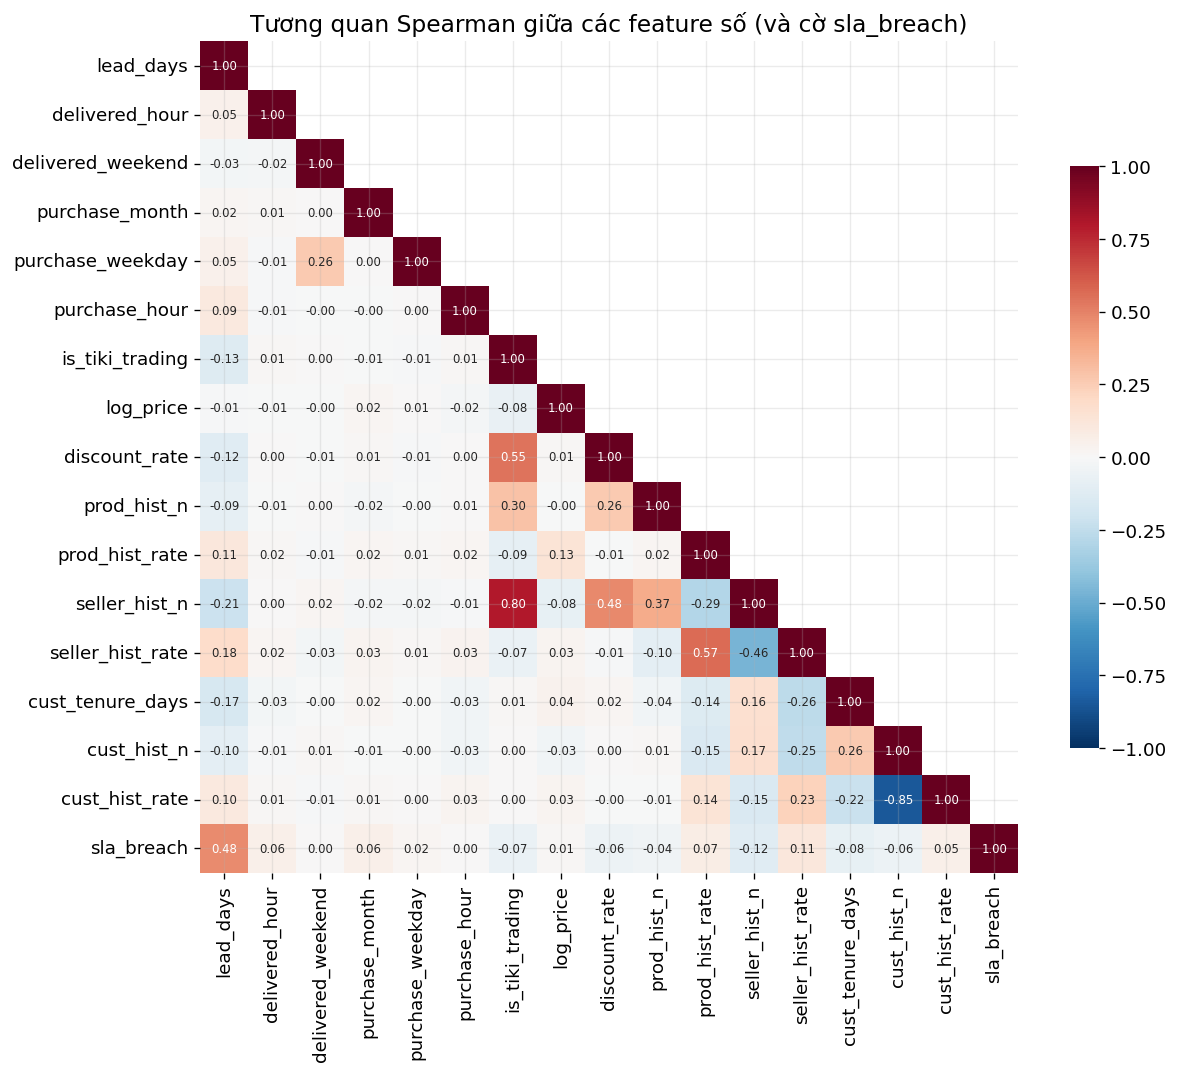

,feature A,feature B,rho
119,cust_hist_rate,cust_hist_n,-0.8511
61,seller_hist_n,is_tiki_trading,0.8036
76,seller_hist_rate,prod_hist_rate,0.5672
34,discount_rate,is_tiki_trading,0.5467
63,seller_hist_n,discount_rate,0.4819
120,sla_breach,lead_days,0.4759


In [17]:
corr = frame[NUMERIC + [SLA_FEATURE]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Tương quan Spearman giữa các feature số (và cờ sla_breach)")
plt.show()

pairs = (corr.where(~mask & ~np.eye(len(corr), dtype=bool)).stack().rename("rho").reset_index()
         .assign(abs_rho=lambda d: d["rho"].abs()).sort_values("abs_rho", ascending=False).head(6))
display(pairs.drop(columns="abs_rho").rename(columns={"level_0": "feature A", "level_1": "feature B"}))

* Hai cặp tương quan mạnh: `cust_hist_n`–`cust_hist_rate` (−0,85 — khách chưa có lịch sử thì tỉ lệ bằng prior) và
  `seller_hist_n`–`is_tiki_trading` (0,80 — Tiki Trading là nhà bán lớn nhất). Không cặp nào trùng tuyệt đối nên giữ cả
  hai: logistic xử lý đa cộng tuyến bằng **phạt L2** (`C` nhỏ — mục chọn siêu tham số), cây không bị ảnh hưởng.
* `gap_days = lead_days − 5` (tương quan đúng 1) và `sla_status` bị loại hẳn (mục 7). `sla_breach` chỉ là một ngưỡng của
  `lead_days` → không đưa vào mô hình đầy đủ, chỉ dùng cho baseline.

## 7. Kiểm toán leakage — cột nào KHÔNG được làm feature?

Một cột chỉ được làm feature nếu giá trị của nó **đã biết lúc đơn được giao**. Danh sách cấm (kèm lý do) nằm trong
`src/features/leakage.py` và được kiểm tự động mỗi khi khai báo tập feature:

In [18]:
display(pd.Series(FORBIDDEN, name="lý do bị cấm").to_frame())

,lý do bị cấm
rating,chính là biến gốc của nhãn is_low_rating
is_low_rating,biến mục tiêu
stratum,tầng lấy mẫu = số sao của review → chính là nhãn
stratum_size,số review cùng số sao của sản phẩm → hàm của nhãn
stratum_sampled,số review đã cào ở tầng sao đó → hàm của nhãn
weight,w = N_h/n_h phụ thuộc tầng sao → hàm của nhãn;...
title,tiêu đề Tiki tự sinh theo số sao (vd 'Cực kì h...
content,văn bản viết cùng lúc với số sao — dùng nó là ...
thank_count,lượt 'cảm ơn' người khác bấm SAU khi review đă...
rating_average,điểm TB sản phẩm lúc cào — chứa chính review c...


**Ví dụ "nhãn đội lốt":** cột `title` trông như văn bản bình thường, nhưng phần lớn là tiêu đề Tiki **tự sinh theo số
sao** khách vừa chấm:

In [19]:
top_titles = clean["title"].value_counts().head(6).index
title_ct = pd.crosstab(clean.loc[clean["title"].isin(top_titles), "title"], clean["rating"], normalize="index")
display(title_ct.style.format("{:.1%}").background_gradient(cmap="Blues", axis=1))
print(f"6 tiêu đề này phủ {clean['title'].isin(top_titles).mean():.1%} số review.\n")

from src.features.leakage import LeakageError, audit_features

try:  # thử khai báo một tập feature có lẫn cột cấm
    audit_features(EX_ANTE_FEATURES + ["title", "customer_says_late"], tier="ex_ante")
except LeakageError as err:
    print(err)

rating,1,2,3,4,5
title,,,,,
Bình thường,0.0%,0.1%,99.6%,0.3%,0.1%
Cực kì hài lòng,0.0%,0.0%,0.1%,0.4%,99.4%
Hài lòng,0.0%,0.1%,0.4%,97.8%,1.7%
Không hài lòng,0.4%,99.2%,0.3%,0.1%,0.1%
Rất không hài lòng,99.7%,0.1%,0.0%,0.1%,0.1%
Tốt,0.0%,0.0%,3.0%,30.1%,66.9%


6 tiêu đề này phủ 97.1% số review.

Vi phạm quy tắc chống leakage:
  - title: tiêu đề Tiki tự sinh theo số sao (vd 'Cực kì hài lòng')
  - customer_says_late: biến hậu nghiệm, chỉ hợp lệ ở tầng ex_post


Đưa `title` vào mô hình thì "dự đoán" đúng gần như tuyệt đối mà không học được gì — chính là nhãn đổi tên. Bộ kiểm toán
`audit_features` chặn mọi tên trong danh sách cấm **ngay khi khai báo** tập feature (ô trên), không đợi tới lúc thấy
metric đẹp bất thường mới phát hiện.

Nhóm **ex-post** — khách khai *cùng lúc* với số sao (bộ câu hỏi giao hàng, số ảnh, độ trễ viết review) — cũng bị loại
khỏi mô hình dự báo. Lý do là **thời điểm**, không phải độ mạnh: lúc đơn vừa giao, các giá trị này chưa tồn tại.

In [20]:
from sklearn.metrics import roc_auc_score

rows = {}
for f in EX_POST_FEATURES:
    d = frame[[f, TARGET, WEIGHT]].dropna()
    rows[f] = {"% dòng có giá trị": len(d) / len(frame),
               "AUC quần thể": roc_auc_score(d[TARGET], d[f], sample_weight=d[WEIGHT])}
display(pd.DataFrame(rows).T.style.format({"% dòng có giá trị": "{:.1%}", "AUC quần thể": "{:.3f}"}))

coverage = frame.groupby(YEAR).apply(lambda d: np.average(d["has_delivery_rating"], weights=d[WEIGHT]))
print("Độ phủ bộ câu hỏi giao hàng theo năm (quần thể):",
      {int(y): f"{v:.1%}" for y, v in coverage.items() if y >= 2019})

,% dòng có giá trị,AUC quần thể
customer_says_late,8.0%,0.541
dr_shipper_bad,8.0%,0.519
dr_gio_giao_bad,8.0%,0.561
dr_dong_goi_bad,8.0%,0.650
has_delivery_rating,100.0%,0.477
n_images,100.0%,0.436
review_lag_days,100.0%,0.481


Độ phủ bộ câu hỏi giao hàng theo năm (quần thể): {2019: '0.0%', 2020: '0.0%', 2021: '0.0%', 2022: '0.0%', 2023: '20.1%', 2024: '31.5%', 2025: '28.6%', 2026: '27.6%'}


Bộ câu hỏi giao hàng chỉ có ở **8%** dòng và **0% trước 2023** — tập train ≤2023 gần như không thấy nó, nên kể cả bỏ
qua vấn đề thời điểm thì cũng không học được. Sức phân biệt của nhóm này (AUC 0,52–0,65) chỉ ngang feature ex-ante. Nhóm
ex-post chỉ được dùng ở mô hình **giải thích** (notebook 03, C9), không ở `main.py`.

## 8. Dữ liệu trôi theo thời gian → cách chia train/test

In [21]:
def year_profile(d: pd.DataFrame) -> pd.Series:
    w = d[WEIGHT].to_numpy(dtype=float)
    return pd.Series({"n": len(d), "lead_days trung vị": float(weighted_quantile(d["lead_days"].to_numpy(), w, 0.5)),
                      "% vượt SLA": np.average(d[SLA_FEATURE], weights=w),
                      "% review ≤3★": np.average(d[TARGET], weights=w),
                      "% có nhãn khách": np.average(d["has_customer_label"], weights=w)})


profile = frame[frame[YEAR] >= 2019].groupby(YEAR).apply(year_profile)
display(profile.style.format({"n": "{:,.0f}", "lead_days trung vị": "{:.2f}", "% vượt SLA": "{:.2%}",
                              "% review ≤3★": "{:.2%}", "% có nhãn khách": "{:.1%}"}))

cv = YearForwardSplit(val_years=(2022, 2023))
print("Train ≤2023 / test 2024–2026:", f"{len(train):,} / {len(test):,} dòng")
print("CV theo năm dùng để chọn siêu tham số (chỉ trên train):")
display(cv.describe(train, train[TARGET]))

,n,lead_days trung vị,% vượt SLA,% review ≤3★,% có nhãn khách
year,,,,,
2019,"3,269",1.83,9.11%,11.79%,0.0%
2020,"18,458",1.68,5.98%,10.61%,0.0%
2021,"52,584",1.70,16.75%,5.19%,0.0%
2022,"54,829",1.17,4.62%,2.83%,0.0%
2023,"26,591",0.98,2.07%,1.95%,20.1%
2024,"18,369",0.91,1.42%,1.66%,31.5%
2025,"14,458",1.04,3.27%,1.68%,28.6%
2026,"8,355",1.51,3.30%,1.72%,27.6%


Train ≤2023 / test 2024–2026: 157,173 / 41,182 dòng
CV theo năm dùng để chọn siêu tham số (chỉ trên train):


,train,val,n_train,n_val,dương_train,dương_val
fold,,,,,,
1,2014–2021,2022,75753,54829,10314,3614
2,2014–2022,2023,130582,26591,13928,1204


Mọi thứ đều trôi theo năm: thời gian giao ngắn dần (trung vị 1,83 → ~1 ngày), năm 2021 vượt SLA tới 16,75% (giãn
cách), tỉ lệ review xấu giảm 7 lần, nhãn khách chỉ xuất hiện từ 2023. Feature lịch sử cũng tích luỹ dần theo thời gian.

⇒ **Không dùng KFold ngẫu nhiên** — nó trộn review 2023 vào train để dự báo 2021, mô hình "nhìn thấy tương lai" và điểm
CV đẹp giả tạo. Thay vào đó:
* **Test = 2024–2026**, chỉ chấm **một lần** sau khi đã chọn xong mọi thứ;
* **CV theo năm (rolling-origin)** trên train để chọn siêu tham số: train ≤2021 → kiểm định 2022, train ≤2022 → kiểm
  định 2023 (`YearForwardSplit`);
* bước tiền xử lý nằm **trong** `Pipeline` nên trung vị/độ lệch chuẩn chỉ được học trên phần train của từng fold;
* `year` không làm feature (cây không ngoại suy được sang năm chưa thấy).

## 9. Luận điểm kinh doanh: SLA đo sai thứ khách quan tâm

### 9.1 Thời gian giao thực tế so với trần SLA 5 ngày

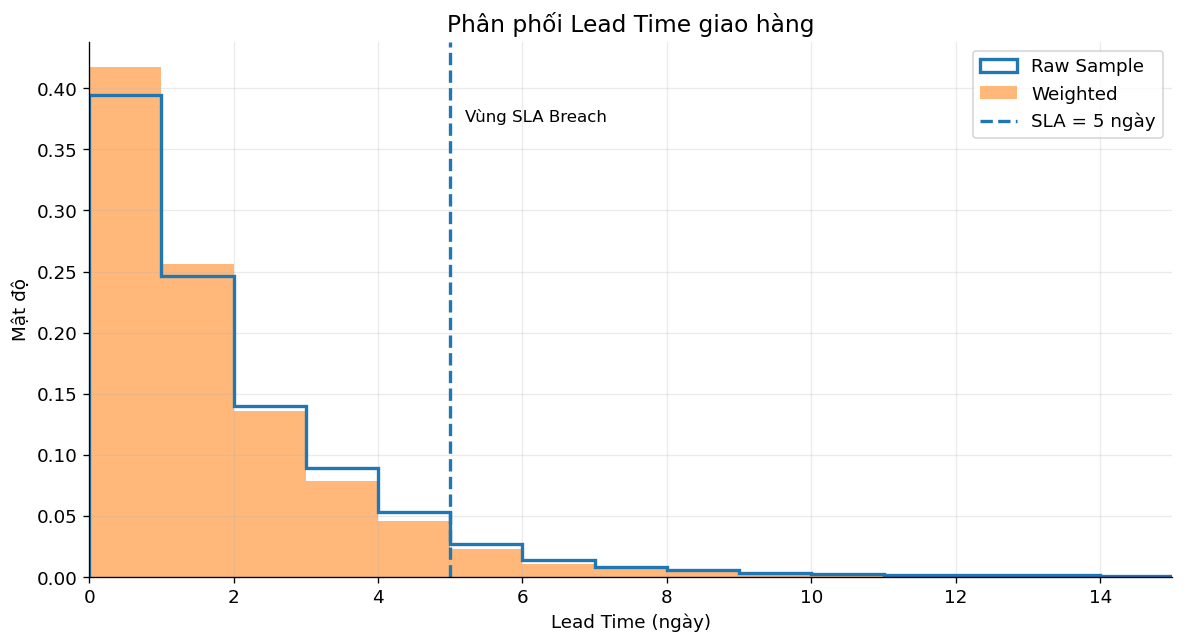

Trung vị có trọng số 1.26 ngày (25% trần SLA) · p90 4.33 ngày · đạt SLA 92.88%


In [22]:
fig, _ = plot_lead_days_hist(clean)
plt.show()
w_ok = ok[WEIGHT].to_numpy(dtype=float)
q50, q90 = weighted_quantile(ok["lead_days"].to_numpy(), w_ok, np.array([0.5, 0.9]))
print(f"Trung vị có trọng số {q50:.2f} ngày ({q50 / 5:.0%} trần SLA) · p90 {q90:.2f} ngày · "
      f"đạt SLA {1 - np.average(ok['sla_breach'].astype(float), weights=w_ok):.2%}")

### 9.2 Tỉ lệ vượt SLA theo năm

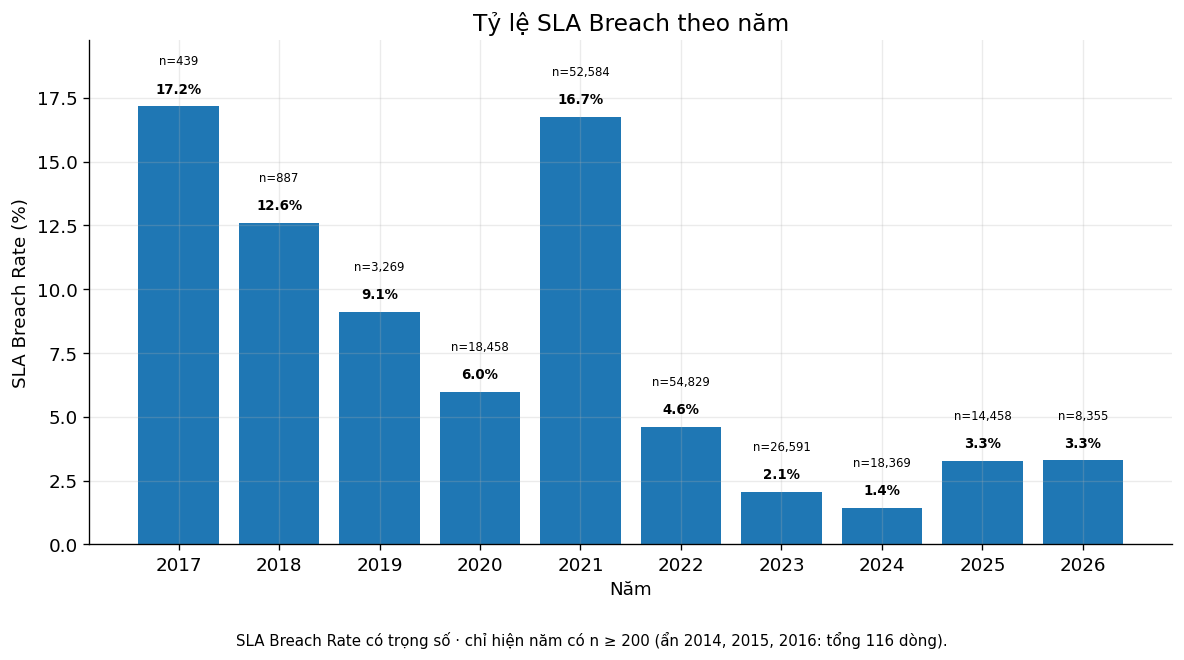

In [23]:
fig, sla_year, _ = plot_sla_by_year(clean)
plt.show()

Tỉ lệ vượt SLA gộp cả mẫu (7,12%) **không** phải tình hình hiện tại: năm 2021 lên 16,75% (giãn cách), còn 2024–2026 chỉ
1,4%–3,3% (bảng mục 8). Khi trích số vượt SLA phải trích theo năm.

### 9.3 Đối chiếu chéo: SLA nói gì, khách nói gì?

Trên các review có nhãn khách tự báo (`dr_thoi_gian`, chỉ có từ 2023), so cờ **vượt SLA** (`lead_days > 5`) với câu trả
lời "Giao đúng hẹn / Giao trễ hẹn" của chính khách hàng.

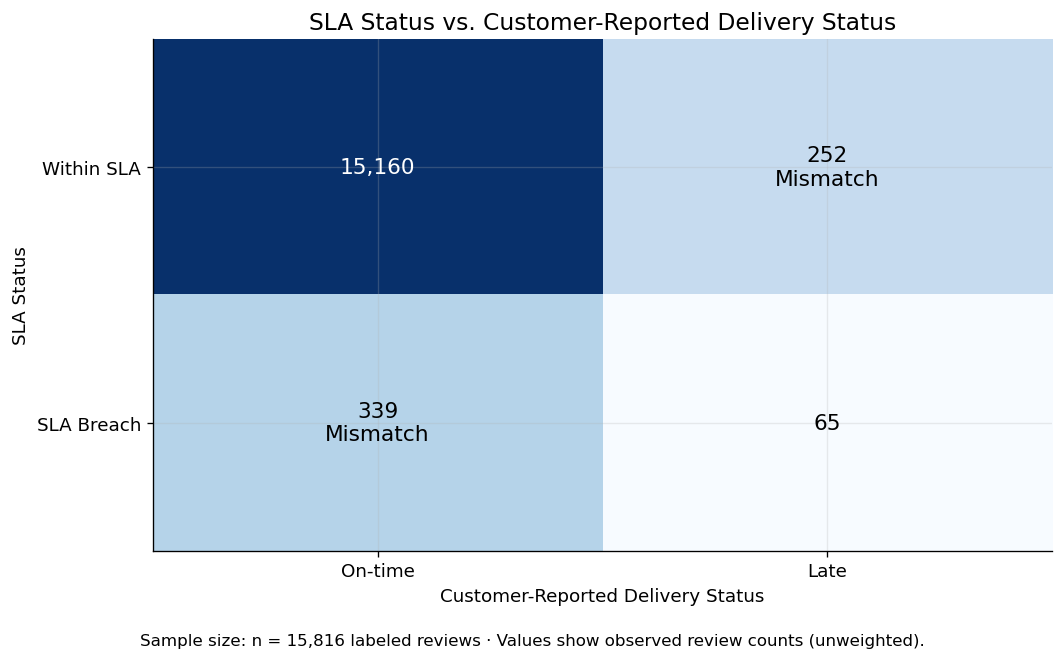

In [24]:
sla_2x2 = plot_sla_2x2(clean)
plt.show()

Hình trên đếm thô. Ba ước lượng chính của đồ án (có trọng số, KTC 95% bằng bootstrap theo cụm sản phẩm, kèm cỡ mẫu
hiệu dụng `n_eff`) — cùng hàm sinh ra số trong báo cáo (`python -m src.evaluate.run_analysis`):

In [25]:
from src.evaluate.run_analysis import key_estimates

estimates = key_estimates(clean)


## Bảng chéo (n = 15,816 review có nhãn)

customer_says_late  Khách: trễ hẹn  Khách: đúng hẹn
sla_status                                         
Giao sớm                       252            15160
Giao trễ                        65              339



## Ước lượng chính

  % than phiền trễ hẹn đến từ đơn TRONG SLA: 83.5254 [75.2118, 89.7647] (95% CI, n=317, n_eff=85, cụm=245)  ⚠️ MONG MANH
  % đơn VƯỢT SLA mà khách nói đúng hẹn: 83.8151 [76.8027, 89.9446] (95% CI, n=404, n_eff=130, cụm=295)
  Chênh lệch sức phân biệt (nhãn khách − SLA): 0.2082 [0.0966, 0.3525] (95% CI, n=15,816, n_eff=4689, cụm=1,916)

  Ghi chú: ước lượng bị gắn ⚠️ MONG MANH có cỡ mẫu hiệu dụng thấp —
  báo cáo dưới dạng khoảng, KHÔNG dùng làm kết luận chính.


* SLA hỏng theo **cả hai chiều**: ~84% đơn khách than "trễ hẹn" lại **nằm trong** SLA (bỏ sót bất mãn thật), và ~84%
  đơn **vượt** SLA thì khách vẫn nói "đúng hẹn" (báo động giả). Ước lượng thứ nhất có `n_eff = 85` < 100 nên chỉ trích
  dưới dạng khoảng.
* **Kết luận chính:** nhãn khách phân biệt mức hài lòng tốt hơn cờ SLA **+0,208 điểm rating, KTC 95% [0,097 · 0,353]**
  — khoảng không chứa 0. Cùng với 92,9% đơn "đạt SLA" và trung vị giao chỉ bằng 25% trần SLA: **tỉ lệ đạt SLA gần như
  không có sức phân biệt để làm chỉ số vận hành.**
* Đây cũng là lý do mô hình dự báo dùng `lead_days` liên tục + lịch sử sản phẩm/nhà bán/khách thay vì cờ SLA — và phải
  có baseline "chỉ cờ SLA" để chứng minh mức chênh.

## 10. Kết luận EDA → quyết định trong pipeline

| # | Phát hiện EDA | Mục | Quyết định trong pipeline (`main.py`) |
|---|---|---|---|
| 1 | Mẫu cào phân tầng theo số sao: mẫu có 8,6% review ≤3★, quần thể chỉ ~4% | 1.4, 3.1 | Mọi metric **nhân trọng số khảo sát** `w = N_h/n_h` (ước lượng quần thể) |
| 2 | 3/16 feature **đảo chiều** quan hệ với nhãn giữa mẫu thô và quần thể | 5.3 | **Train có trọng số** (`model__sample_weight`), không chỉ đánh giá có trọng số |
| 3 | Lớp dương hiếm và hiếm dần: 4,45% train (21,5 : 1), 1,68% test (58,6 : 1) | 3.2 | Thước đo chính **PR-AUC**, không accuracy; `class_weight` ∈ {None, balanced, 1:21,5} là siêu tham số do CV chọn; không SMOTE |
| 4 | Tỉ lệ review xấu, thời gian giao, độ phủ nhãn đều **trôi theo năm** | 3.2, 8 | Chia **theo thời gian**: train ≤2023 · test 2024–2026; CV `YearForwardSplit` (val 2022, 2023); hiệu chỉnh Platt trên năm 2023 |
| 5 | Chỉ `cust_tenure_days` thiếu (10,3%), và **thiếu = tín hiệu** (review xấu gấp ~3 lần) | 2.2 | `SimpleImputer(median, add_indicator=True)` |
| 6 | Thang đo chênh hàng nghìn lần; logistic có phạt L2 | 4.1 | `StandardScaler` cho cột số |
| 7 | Ngành hàng: biến định danh 10 mức, tỉ lệ xấu 0,9%–9,2% | 4.3 | `OneHotEncoder(handle_unknown="ignore")` |
| 8 | Review xấu tăng **đều** theo `lead_days`, không có vách ở 5 ngày | 5.1 | Dùng `lead_days` liên tục; cờ `sla_breach` chỉ làm **baseline B1** |
| 9 | Lịch sử sản phẩm/nhà bán mạnh nhất; nhiều quan hệ **phi tuyến** | 5.2–5.3 | Ba họ mô hình: Logistic + RandomForest + HistGBM; mô hình chốt = ensemble Logistic + HistGBM |
| 10 | Vài cặp feature tương quan mạnh (Spearman tới −0,85), không trùng tuyệt đối | 6 | Giữ cả; chính quy hoá L2 (`C` do GridSearchCV chọn) |
| 11 | `title`, `rating_average`, `thank_count`, `gap_days`… là nhãn đội lốt / thông tin tương lai; bộ câu hỏi giao hàng là ex-post | 7 | Loại bằng `audit_features` (chặn ngay khi khai báo); chỉ dùng **17 feature ex-ante** |
| 12 | 2,5% dòng không tính được lead time (thiếu mốc, lead âm) — loại không làm lệch rating | 2.3 | Chỉ train/đánh giá trên dòng `is_analysable`; gắn cờ, không xoá im lặng |

**Chạy pipeline:** `python main.py` (≈1–2 phút) · `python main.py --search quick` (GridSearchCV lưới rút gọn) ·
`python main.py --help` để xem mọi tham số.